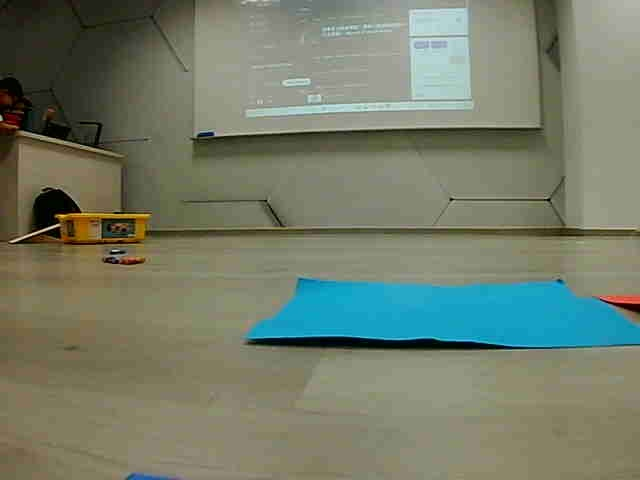

In [4]:
import cv2
import numpy as np
from IPython.display import display, Image, clear_output
import time
from ugot import ugot

# Create the robot controller object
got = ugot.UGOT()

# Connect to the robot — update this IP address if needed
got.initialize("10.210.71.184")

# Load the face recognition model
# This must be loaded before calling any face_recognition functions below
got.load_models(["face_recognition"])

CAMERA_FRAME_WIDTH = 640
CAMERA_FRAME_HEIGHT = 480

# Horizontal dead-zone around frame centre (320 px).
# Objects with center_x inside [LEFT_THRESHOLD, RIGHT_THRESHOLD] are treated as centred.
LEFT_THRESHOLD = 320 - 10
RIGHT_THRESHOLD = 320 + 10

# Ball bounding-box width (px) at which pickup is triggered.
# Increase if the robot is grabbing from too far away; decrease if it overshoots.
RED_BALL_PICKUP_THRESHOLD = 160

# Face bounding-box width (px) at the ideal throwing distance.
# Use the Face-Annotated Camera Feed to find the right value for your arena.
FACE_WIDTH_APPROACH_THRESHOLD = 80

# ± tolerance on the face width target — prevents the robot oscillating around the goal.
FACE_WIDTH_APPROACH_TOLERANCE = 10

# Initial FSM state
state = "Ball Search"

# --- Red ball HSV colour ranges ---
# Red wraps around 0° in the OpenCV hue circle, so two ranges are required.
RED_HSV_LOWER_1 = np.array([0, 70, 70])  # low-hue red  (0–10°)
RED_HSV_UPPER_1 = np.array([10, 255, 255])
RED_HSV_LOWER_2 = np.array([170, 70, 70])  # high-hue red (170–180°)
RED_HSV_UPPER_2 = np.array([180, 255, 255])

got.open_camera()

def red_ball_pickup(img, state):
    """Detect the red ball and drive toward it; pick it up when close enough.

    Only active in the 'Ball Search' state. Steers the robot to keep the ball
    centred in the frame and drives forward until the ball's bounding-box width
    exceeds RED_BALL_PICKUP_THRESHOLD, then executes the arm pickup sequence.

    Args:
        img:   BGR image from the camera (annotated in-place for the debug display).
        state: Current FSM state string.

    Returns:
        Updated state string ('Ball Search' or 'Search Face').
    """
    if state == "Ball Search":
        # Convert frame to HSV for colour-range detection
        hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

        # Build a binary mask covering both red hue ranges, then combine with OR
        mask1 = cv2.inRange(hsv_img, RED_HSV_LOWER_1, RED_HSV_UPPER_1)
        mask2 = cv2.inRange(hsv_img, RED_HSV_LOWER_2, RED_HSV_UPPER_2)
        mask = cv2.bitwise_or(mask1, mask2)

        # Find contours of the masked (red) regions
        # RETR_TREE retrieves the full contour hierarchy (overkill here, but harmless)
        contours, _ = cv2.findContours(mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

        if contours:
            # Work with the largest red region to ignore small noise blobs
            largest_contour = max(contours, key=cv2.contourArea)
            area = cv2.contourArea(largest_contour)

            if area > 500:  # Minimum area threshold — filters out tiny noise specks
                # Get the axis-aligned bounding box: top-left (x,y), width w, height h
                x, y, w, h = cv2.boundingRect(largest_contour)
                center_x = x + w // 2
                center_y = y + h // 2

                # Annotate the debug frame with box and label
                cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 255), 2)
                label = f"Center_x: {center_x} Area:{area} w:{w}"
                cv2.putText(
                    img,
                    label,
                    (x, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    (0, 255, 255),
                    2,
                )

                if w > RED_BALL_PICKUP_THRESHOLD:
                    # Ball is large enough (close enough) — execute pickup sequence
                    got.mecanum_stop()
                    time.sleep(1)

                    # Open gripper, lower arm to ball level, close gripper, raise arm
                    # joint_control(j1_base, j2_mid, j3_tip, duration_ms)
                    # Negative j2/j3 angles tilt the arm downward toward the floor.
                    got.mechanical_clamp_release()  # Open gripper
                    got.mechanical_joint_control(0, -45, -23, 1500)  # Lower arm to ball
                    time.sleep(2)  # Wait for arm to reach position
                    got.mechanical_clamp_close()  # Grab the ball
                    time.sleep(1)  # Wait for gripper to close
                    got.mechanical_joint_control(
                        0, 50, 80, 1500
                    )  # Raise arm to carry position
                    state = "Search Face"  # Ball is in hand — move to next phase

                elif center_x < LEFT_THRESHOLD:
                    # Ball is to the left of centre — strafe left to align
                    got.mecanum_move_xyz(-5, 0, 0)
                elif center_x > RIGHT_THRESHOLD:
                    # Ball is to the right of centre — strafe right to align
                    got.mecanum_move_xyz(5, 0, 0)
                else:
                    # Ball is centred but not yet close enough — drive forward
                    got.mecanum_move_xyz(0, 5, 0)

    return state

try:
    while True:
        # Read and decode a raw frame from the robot camera
        frame = got.read_camera_data()
        nparr = np.frombuffer(frame, np.uint8)
        img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

        if img is not None:
            # Encode the frame as JPEG and push it to the notebook output
            _, jpeg = cv2.imencode(".jpg", img)
            clear_output(wait=True)
            display(Image(data=jpeg.tobytes()))

        # Query the face recognition model.
        # Returns a list of faces; each entry is [name, cx, cy, height, width, area].
        # Returns an empty list [] if no faces are detected.
        faces = got.get_face_recognition_total_info()

        # Read and decode the current camera frame
        frame = got.read_camera_data()
        nparr = np.frombuffer(frame, np.uint8)
        img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

        if img is None:
            continue

        # Draw annotations for every detected face
        for face in faces:
            name, center_x, center_y, height, width, area = face

            # Convert centre + half-dimensions to bounding box corners
            left = int(center_x - width // 2)
            right = int(center_x + width // 2)
            top = int(center_y - height // 2)
            bottom = int(center_y + height // 2)

            # Green bounding box around the face
            cv2.rectangle(img, (left, top), (right, bottom), (0, 255, 0), 2)

            # Red dot at the face centre
            cv2.circle(img, (int(center_x), int(center_y)), 5, (0, 0, 255), -1)

            # Full data label: name, position, dimensions, area
            label = (
                f"{name} "
                f"X:{center_x} "
                f"Y:{center_y} "
                f"W:{width} "
                f"H:{height} "
                f"A:{area}"
            )
            cv2.putText(
                img,
                label,
                (left, top - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0, 255, 0),
                2,
            )

        # Encode and display the annotated frame
        _, jpeg = cv2.imencode(".jpg", img)
        clear_output(wait=True)
        display(Image(data=jpeg.tobytes()))
        break

    # Reset the arm to a safe carry position before the routine starts
    # j2=50, j3=80 tilts the arm upward and back so it doesn't obstruct the camera
    got.mechanical_joint_control(0, 50, 80, 1000)
    got.mechanical_clamp_close()  # Ensure gripper starts closed

    while True:
        # --- Read sensor data every frame ---
        # Face data is read at the top of the loop so it's always fresh for all states
        faces = got.get_face_recognition_total_info()
        frame = got.read_camera_data()
        nparr = np.frombuffer(frame, np.uint8)
        img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

        if img is not None:

            # ============================================================
            # FSM — one state is executed per frame
            # ============================================================

            if state == "Ball Search":
                # Delegate to helper function; it returns the (possibly updated) state
                state = red_ball_pickup(img, state)

            elif state == "Search Face":
                # Drive forward slowly until the face recognition model sees someone
                if faces == []:
                    # No faces yet — keep moving forward to sweep the area
                    got.mecanum_move_xyz(0, 10, 0)
                else:
                    # At least one face detected — stop and transition to approach
                    got.mecanum_stop()
                    state = "Approach Face"

            elif state == "Approach Face":
                # Process each detected face (in practice, usually just one)
                for face in faces:
                    name, center_x, center_y, height, width, area = face

                    # Compute bounding box corners for the annotation overlay
                    left = int(center_x - width // 2)
                    right = int(center_x + width // 2)
                    top = int(center_y - height // 2)
                    bottom = int(center_y + height // 2)

                    # Annotate the debug frame
                    cv2.rectangle(img, (left, top), (right, bottom), (0, 255, 0), 2)
                    label = f"{name} Center_x: {center_x} Area:{area}"
                    cv2.putText(
                        img,
                        label,
                        (left, top - 10),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.5,
                        (0, 255, 0),
                        2,
                    )

                    if name == 'Bad Guy':

                        # Use face width as a distance proxy:
                        # wider = closer, narrower = farther
                        lower_bound = (
                            FACE_WIDTH_APPROACH_THRESHOLD - FACE_WIDTH_APPROACH_TOLERANCE
                        )
                        upper_bound = (
                            FACE_WIDTH_APPROACH_THRESHOLD + FACE_WIDTH_APPROACH_TOLERANCE
                        )

                        if width < lower_bound:
                            # Face is too small (too far) — drive forward
                            got.mecanum_move_xyz(0, 10, 0)
                        elif width > upper_bound:
                            # Face is too large (too close) — reverse
                            got.mecanum_move_xyz(0, -10, 0)
                        else:
                            # Face width is within the target range — in throwing position
                            got.mecanum_stop()

                            # Adjust the arm's base rotation (joint 1) to aim at the target.
                            # j1 positive = rotate left; negative = rotate right.
                            # j2=-5 tilts the arm slightly forward for the throw.
                            if center_x < LEFT_THRESHOLD:
                                # Target is on the left — rotate arm left
                                got.mechanical_joint_control(10, -5, 0, 100)
                            elif center_x > RIGHT_THRESHOLD:
                                # Target is on the right — rotate arm right
                                got.mechanical_joint_control(-10, -5, 0, 100)
                            else:
                                # Target is centred — aim straight ahead
                                got.mechanical_joint_control(0, -5, 0, 100)

                            # Release the ball to complete the throw
                            got.mechanical_clamp_release()
                            got.mecanum_stop()
                            time.sleep(2)  # Brief pause before ending
                            state = "Done"

            elif state == "Done":
                # Routine complete — hold position
                got.mecanum_stop()

            # Encode and push the annotated frame to the notebook output
            _, jpeg = cv2.imencode(".jpg", img)
            clear_output(wait=True)
            display(Image(data=jpeg.tobytes()))

except KeyboardInterrupt:
    got.mecanum_stop()